### This notebook illustrates the main ideas of the BMS vs ANN approximation at one-dimensional functions.

In [68]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyrenn
sns.set(style='ticks')
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.interpolate import griddata
from scipy.stats import spearmanr
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from pickle import load
import matplotlib.gridspec as gridspec
import ast
import sys
BMS_path='../bin/'
sys.path.append(BMS_path + 'no_degeneracy/')
sys.path.append(BMS_path + 'no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Functions and figure settings

In [69]:
#A function to return mdl models from traces
#------------------------------------------------------
def get_mdl(df_var, trace_var,dimensions=False ):
    
    #Parameters to read models
    if dimensions==True:
         VARS = ['x','y',]
         prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv2.np10.2016-09-09 18:49:42.600380.dat')
    else:
        VARS = ['x',]
        prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')

    #one or two dimensional nguyen functions
    try:
        x = df_var[[c for c in VARS]].copy()
        y=df_var.z_noise
    except KeyError:
        VARS = ['x1',]
        x = df_var[[c for c in VARS]].copy()
        y=df_var.y_noise
        
    
    minrow = trace_var[trace_var.H == min(trace_var.H)].iloc[0]
    minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)
    
    tvar= Tree(
        variables=list(x.columns),
        parameters=['a%d' % i for i in range(NPAR)],
        x=x, y=y,
        prior_par=prior_par,
        max_size=200,
        from_string=minexpr,
    )

    tvar.set_par_values(deepcopy(minparvals))
    x_var=x;y_var=y
    
    return tvar, x_var, y_var
#------------------------------------------------------

#Figure settings
#--------------------------------

#Paths, extensions, and figure size
#--------------------------------
output_path='../results/'      
extensions=['.pdf', '.png']    
#Define figure size in cm
cm = 1/2.54 #convert inch to cm
width = 8*cm; height=7*cm 
#--------------------------------

#Text and figure sizes  
#--------------------------------
size_axis=16;size_ticks=12;size_title=8
line_w=1.5;marker_s=3
#--------------------------------

#Colors
#----------------------------------------------
color_data=sns.color_palette("colorblind")[0]
color_noise=sns.color_palette("colorblind")[7]
color_ann=sns.color_palette("colorblind")[4]
color_bms=sns.color_palette("colorblind")[2]
#-----------------------------------------------

#ticks and limits for ann 
#--------------------------------
xtick_labels=[-2, 0, 2 ];ytick_labels=[ 0, 0.5, 1.0]
xmin=-2.04;xmax=2.04;ymin=-0.1;ymax=1.01
#--------------------------------

#ticks and limits for ng1 functions
#--------------------------------
xtick_labels_ng1=[-1, 0, 1 ];ytick_labels_ng1=[ -3, 0, 3, 6.0]
xmin_ng1=-1.1;xmax_ng1=1.1;ymin_ng1=-3.25;ymax_ng1=7
#--------------------------------

#ticks and limits for ng10 functions
#--------------------------------
xtick_labels_ng10=[0, 0.5, 1 ];ytick_labels_ng10=[ 0, 0.5, 1.0];ztick_labels_ng10=[ 0, 0.5, 1.0]
xmin_ng10=-0.1;xmax_ng10=1.1;ymin_ng10=-0.1;ymax_ng10=1.1;
zmin_ng10=-0.1;zmax_ng10=1
#--------------------------------



## Read input data

In [71]:
#Read ANN-generated data and model                                                                                        
activation_function='tanh'; n=7;sigma=0.0; realization=2  #parameters
path_nn='../data/tutorial/'
file_data= path_nn + 'NN_no_overfit_test_full_train_tanh_sigma_0.0_r_0.csv'
d=pd.read_csv(file_data, index_col=0)
dn=d[d['rep']==n] #select n=7
dn=dn[(dn['x1']>=-2.0) & (dn['x1']<=2.0)] #take points between x=-2/+2
display(dn)

#Read BMS with 10 parameters and run in 50 k steps
steps=50000;NPAR=10
path_trace= '../data/MSTraces/'
filename=path_trace +'BMS_test_' + activation_function + '_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_trace_'+str(steps)+'_prior_10'+ '.csv'

trace0=pd.read_csv(filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
t0,x0,y0=get_mdl(dn, trace0)

,x1,y,rep,noise,y_noise,ymodel
0,-1.95,0.000742,7.0,0.0,0.000742,0.000196
1,-1.90,0.000555,7.0,0.0,0.000555,0.000264
2,-1.85,0.000384,7.0,0.0,0.000384,0.000314
3,-1.80,0.000236,7.0,0.0,0.000236,0.000348
4,-1.75,0.000117,7.0,0.0,0.000117,0.000369
...,...,...,...,...,...,...
75,1.80,0.128330,7.0,0.0,0.128330,0.128808
76,1.85,0.132584,7.0,0.0,0.132584,0.132863
77,1.90,0.137246,7.0,0.0,0.137246,0.137183
78,1.95,0.142347,7.0,0.0,0.142347,0.141764


<lambdifygenerated-1082>:2: RuntimeWarning: invalid value encountered in power
  return x1**x1/x1
<lambdifygenerated-1083>:2: RuntimeWarning: invalid value encountered in power
  return x1**x1/x1
<lambdifygenerated-1084>:2: RuntimeWarning: invalid value encountered in power
  return (2*x1)**x1/x1
<lambdifygenerated-1085>:2: RuntimeWarning: invalid value encountered in power
  return (2*x1)**x1/x1
<lambdifygenerated-1086>:2: RuntimeWarning: invalid value encountered in power
  return (x1**2 + x1)**x1/x1
<lambdifygenerated-1087>:2: RuntimeWarning: invalid value encountered in power
  return (x1**2 + x1)**x1/x1
<lambdifygenerated-1088>:2: RuntimeWarning: invalid value encountered in power
  return (x1*x1**x1 + x1)**x1/x1
<lambdifygenerated-1089>:2: RuntimeWarning: invalid value encountered in power
  return (x1*x1**x1 + x1)**x1/x1
<lambdifygenerated-1090>:2: RuntimeWarning: invalid value encountered in power
  return (x1*sin(x1)**x1 + x1)**x1/x1
<lambdifygenerated-1091>:2: RuntimeWarning:

### Consider the example function read in the previous cell

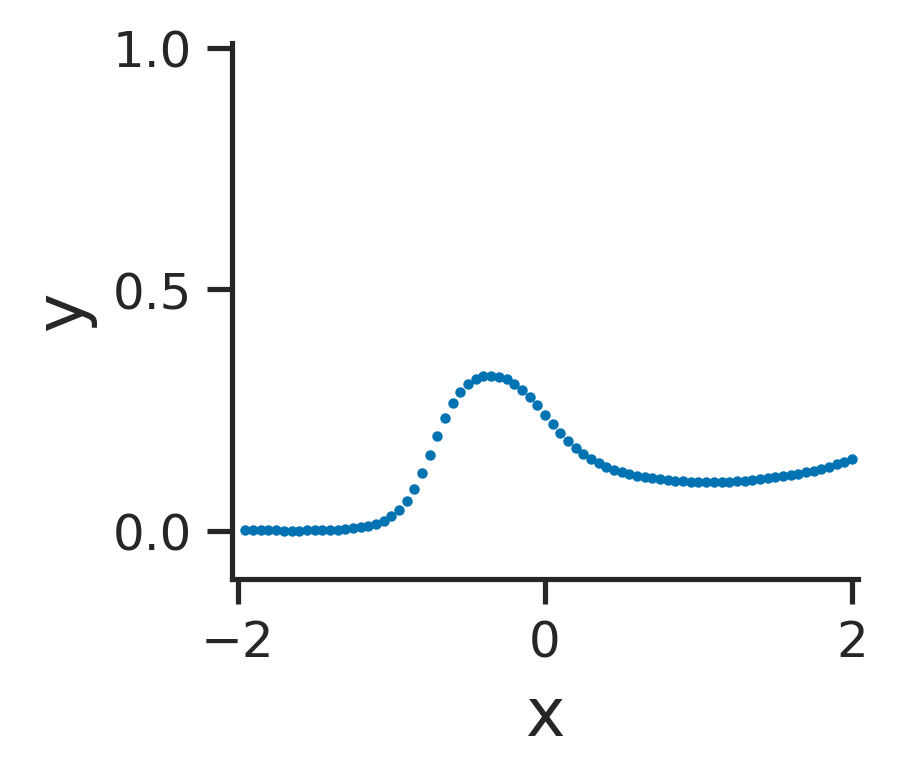

In [46]:
#Plot example function
#--------------------------------            
fig=figure(figsize=(width,height), dpi=300) 
plt.plot(dn.x1,dn.y,'.', color=color_data, markersize=marker_s)
#--------------------------------  

#Labels and ticks                                                              
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)                                                              
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(ytick_labels, fontsize=size_ticks)
plt.xlim(xmin,xmax);plt.ylim(ymin,ymax)

sns.despine(top=True, right=True);fig.tight_layout()

#save fig  
name_fig='observed_data'
for ext in extensions:
    plt.savefig(output_path+name_fig+ext,dpi=300)

plt.show()
#-------------------------------- 

# Suppose we approximate the function with a neural network:

![alt text](figures/ann_1.png "ANN with 5 layers and 10 nodes per layer")

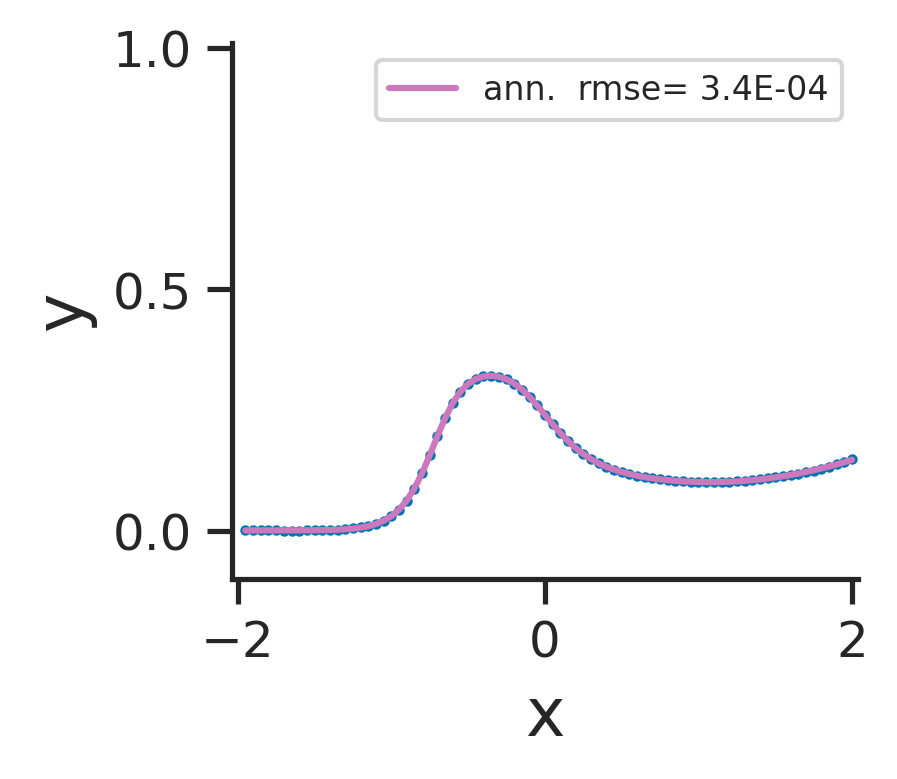

In [48]:
fig=figure(figsize=(width,height), dpi=300) 

#calculate root mean squared error
rmse_nn_total=root_mean_squared_error(dn.ymodel,dn.y)

#Plots                                                               
#--------------------------------                                    
plt.plot(dn.x1,dn.y,'.', color=color_data,markersize=marker_s)
plt.plot(dn.x1,dn.ymodel, color=color_ann, label='ann.  rmse= %.1E' % rmse_nn_total)
#--------------------------------

#Labels                                                              
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
#Ticks                                                               
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(ytick_labels, fontsize=size_ticks)
plt.xlim(xmin,xmax);plt.ylim(ymin,ymax)

plt.legend(loc='best', fontsize=size_title)

sns.despine(top=True, right=True)
fig.tight_layout()

#save fig  
#name_fig='ann_full_prediction'
#for ext in extensions:
#    plt.savefig(output_path+name_fig+ext,dpi=300)

plt.show()
#-------------------------------- 

# Suppose now that we train the Bayesian Machine Scientist with 10 parameters and let it sample the space in 50k steps

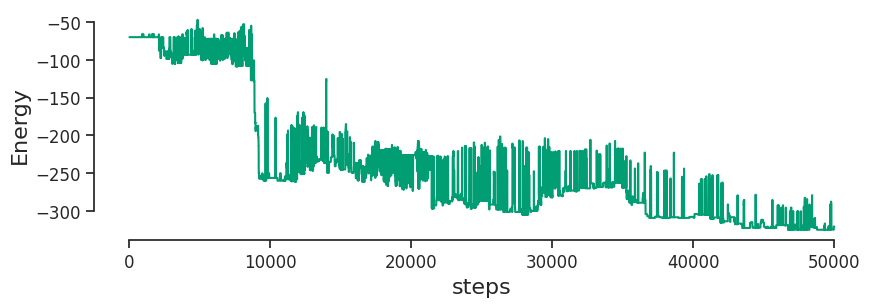

In [49]:
#Plot energy vs steps
plt.figure(figsize=(10, 3))

Nini = 00
minrow = trace0[trace0.H == min(trace0.H)].iloc[0]
#minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)

plt.plot(trace0.t[trace0.t > Nini], trace0.H[trace0.t > Nini],color=color_bms)

plt.xlabel('steps',fontsize=size_axis);plt.ylabel('Energy',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)

sns.despine(trim=True)
namefig='Energy_' + activation_function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

for ext in extensions:
        plt.savefig(output_path + namefig + ext,dpi=300)

 
plt.show()

# Let's plot the approximation of the equation generated by the BMS

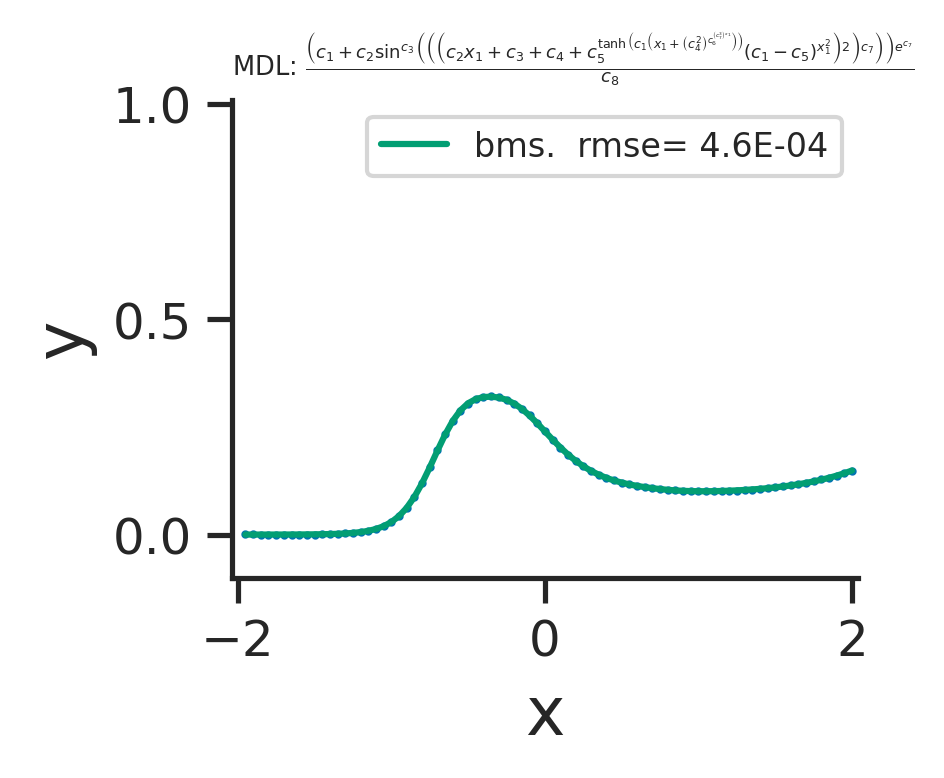

In [50]:

#copy the original dataframe and add a column for the prediction of the BMS
dplot = deepcopy(dn)
dplot['ybms'] = t0.predict(x0)

#calculate rmse
rmse_mdl=root_mean_squared_error(dplot['ybms'],dn['y'])

#Define figure size in cm                                                                                                                                   
fig=figure(figsize=(width,height), dpi=300) 
plt.plot(dn['x1'], dn['y'],'.', markersize=2, color=color_data) 
plt.plot(dplot.x1, dplot.ybms, color=color_bms,label='bms.  rmse= %.1E' % ( rmse_mdl))


plt.title('MDL: $%s$' % t0.latex(),loc='left',fontsize=size_title-1.8)
plt.xlabel('x',fontsize=size_axis);plt.ylabel("y",fontsize=size_axis)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(ytick_labels, fontsize=size_ticks)
plt.xlim(xmin,xmax);plt.ylim(ymin,ymax)  

plt.legend(loc='best', fontsize=size_title)

sns.despine(top=True, right=True)
fig.tight_layout()

#namefig='bms_full_prediction'
#for ext in extensions:
#        plt.savefig(output_path + namefig +ext,dpi=300)

plt.show()


## The equation found by the BMS approximates the same function with an error on the same order of magnitude and just 10 parameters

You think that is a complex equation? Probably, but bear in mind that the ANN that I showed you above performs 522 operations per data point. That function has 80 points.

Now, this is just an example, of course, so we do two experiments: 

### Experiment 1: Can ANNs and the BMS approximate actual mathematical functions?

 To see that, we take two functions from the [Nguyen Dataset](https://doi.org/10.1007/978-3-642-04962-0_7). In particular, we take function 1 and 10:

$$f_1=3.39 x^3 + 2.12 x^2 +  1.78 x$$

$$f_{10}=\sin(1.5 x) \cos(0.5 y)$$

First, we read the datasets.

In [51]:
#Read Nguyen data

#Read NN data
#-------------------------------------------------------------------------------
sigma=0.0;

realization=2

NPAR=10 #10, 20
steps=50000
path_nguyen_nn= '../data/nns/nguyen/'
file_model_ng1= path_nguyen_nn + 'NN_no_overfit_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
dng=pd.read_csv(file_model_ng1,index_col=0)


#Read n1 trace
#-------------------------------------------------------------------------------
n1=1
dng1=dng[dng['rep']==1]
#Read bms trace for nguyen 1
path_nguyen_bms='../data/MSTraces/nguyen/'
trace_ng1=path_nguyen_bms + 'BMS_nguyen_n_' + str(n1)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_id_0_trace_'+str(steps)+'_prior_10'+ '.csv'
trace1=pd.read_csv(trace_ng1, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
t1,x1,y1=get_mdl(dng1, trace1)
#-------------------------------------------------------------------------------

#Read n10 trace
#-------------------------------------------------------------------------------
n2=10
dng10=dng[dng['rep']==n2]
dng10=dng10.reset_index(drop=True)
trace_ng10=path_nguyen_bms + 'BMS_nguyen_n_' + str(n2)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_id_0_trace_'+str(steps)+'_prior_10'+ '.csv'
trace10=pd.read_csv(trace_ng10, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
t10,x10,y10=get_mdl(dng10, trace10,dimensions=True)
#-------------------------------------------------------------------------------

### Then we plot the actual functions

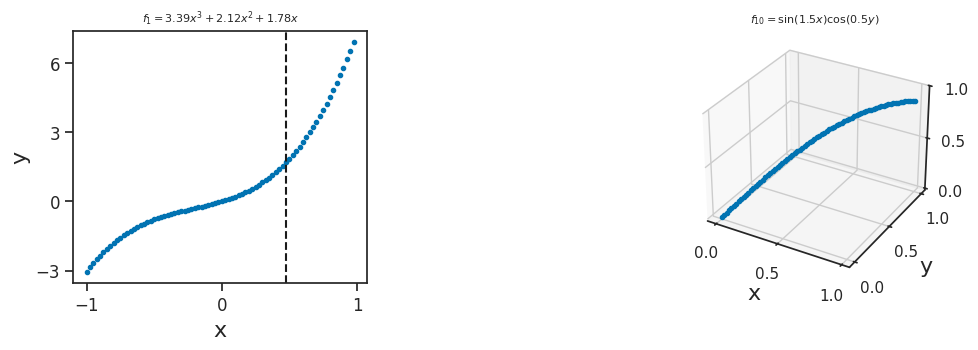

In [52]:
#Plot nguyen function 1

train_size=60
train_border=dng1.loc[train_size-1]['x']

width_p=30*cm;height_p=20*cm #Width and height of plots                                                  
matplotlib.rcParams['figure.figsize'] = [width_p, height_p]
rows=2;cols=3
gs=gridspec.GridSpec(rows,cols)
gs.update(left=0.05,right=0.97,bottom=0.1,top=0.95,wspace=0.35,hspace=0.65)


#Nguyen1                                                                                             
ax_00=plt.subplot(gs[0,0])
plt.title(r'$f_1=3.39 x^3 + 2.12 x^2 +1.78x$',fontsize=size_title)
plt.plot(dng1.x,dng1.z, '.', color=color_data, label='f1')
plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(xtick_labels_ng1, fontsize=size_ticks);plt.yticks(ytick_labels_ng1, fontsize=size_ticks)


#Nguyen5                                                                                             
ax_01 = plt.subplot(gs[0,1:3], projection='3d')
plt.title(r'$f_{10}=\sin(1.5x) \cos(0.5y)$',fontsize=size_title)
ax_01.plot(dng10.x, dng10.y, dng10.z, '.',color=color_data)
                                                     
ax_01.set_xticks(xtick_labels_ng10);ax_01.set_yticks(ytick_labels_ng10);ax_01.set_zticks(ztick_labels_ng10)
ax_01.set_xlabel('x',fontsize=size_axis);ax_01.set_ylabel('y',fontsize=size_axis);ax_01.set_zlabel('z',fontsize=size_axis)

plt.show()


### And now we plot the approximations of ANNs (red solid line) and the equation found by the BMS (solid green line) for $$f_1=3.39 x^3 + 2.12 x^2 +  1.78 x$$

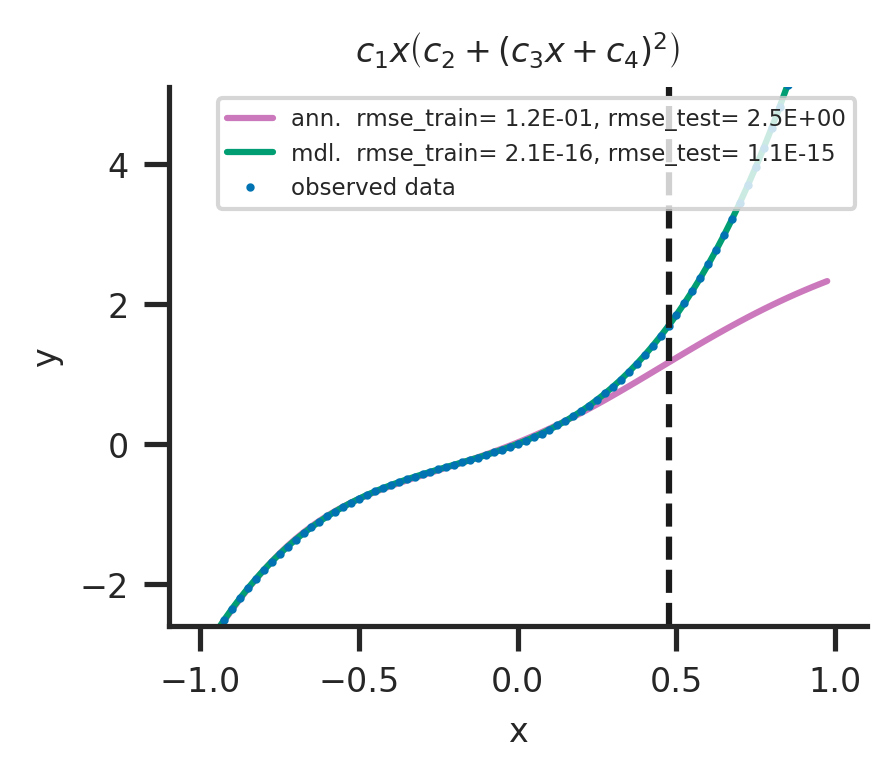

((_a2_ * x) * ((((x * _a0_) + _a3_) ** 2) + _a1_)) {'d0': {'_a0_': 2.128053445968343, '_a1_': 1.9350857962573627, '_a2_': 0.7485738229658999, '_a3_': 0.665409042102196, '_a4_': 1.0, '_a5_': 1.0, '_a6_': 1.0, '_a7_': 1.0}}


In [54]:
train_size_ann=50
train_size=60

train_border=dng1.loc[train_size-1]['x']

dplot = deepcopy(dng1)
dplot['ybms'] = t1.predict(x1)

#Errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size-1]['zmodel'],dplot.loc[:train_size -1]['z'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size-1:]['zmodel'],dplot.loc[train_size -1:]['z'])
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size-1]['ybms'],dplot.loc[:train_size-1]['z'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size-1:]['ybms'],dplot.loc[train_size-1:]['z'])


#Plot figure
fig=figure(figsize=(width,height), dpi=300)                                                        
plt.plot(dng1['x'], dng1['zmodel'],linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.1E, rmse_test= %.1E' % ( rmse_nn_train, rmse_nn_test)) 
plt.plot(dplot.x, dplot.ybms, color=color_bms,label='mdl.  rmse_train= %.1E, rmse_test= %.1E' % ( rmse_mdl_train, rmse_mdl_test)) 
plt.plot(dng1['x'], dng1['z'],'.', markersize=2, color=color_data,label='observed data')  
                                                                                
plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')


plt.title('$%s$' % t1.latex(),fontsize=size_title)
plt.xlabel('x',fontsize=size_title);plt.ylabel('y',fontsize=size_title)
plt.xticks(fontsize=size_title);plt.yticks(fontsize=size_title)

plt.legend(loc='best', fontsize=size_title-2.5)

plt.xlim(-1.1, 1.1);plt.ylim(-2.6,5.1)

sns.despine(top=True, right=True)
fig.tight_layout()

Name_figure='prediction_nguyen' + '_n_1' + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

    
for ext in extensions:
        plt.savefig('../results/' + Name_figure +ext,dpi=300)

plt.show()


print(t1,t1.par_values)

### We do the same for: $$f_{10}=\sin(1.5 x) \cos(0.5 y)$$

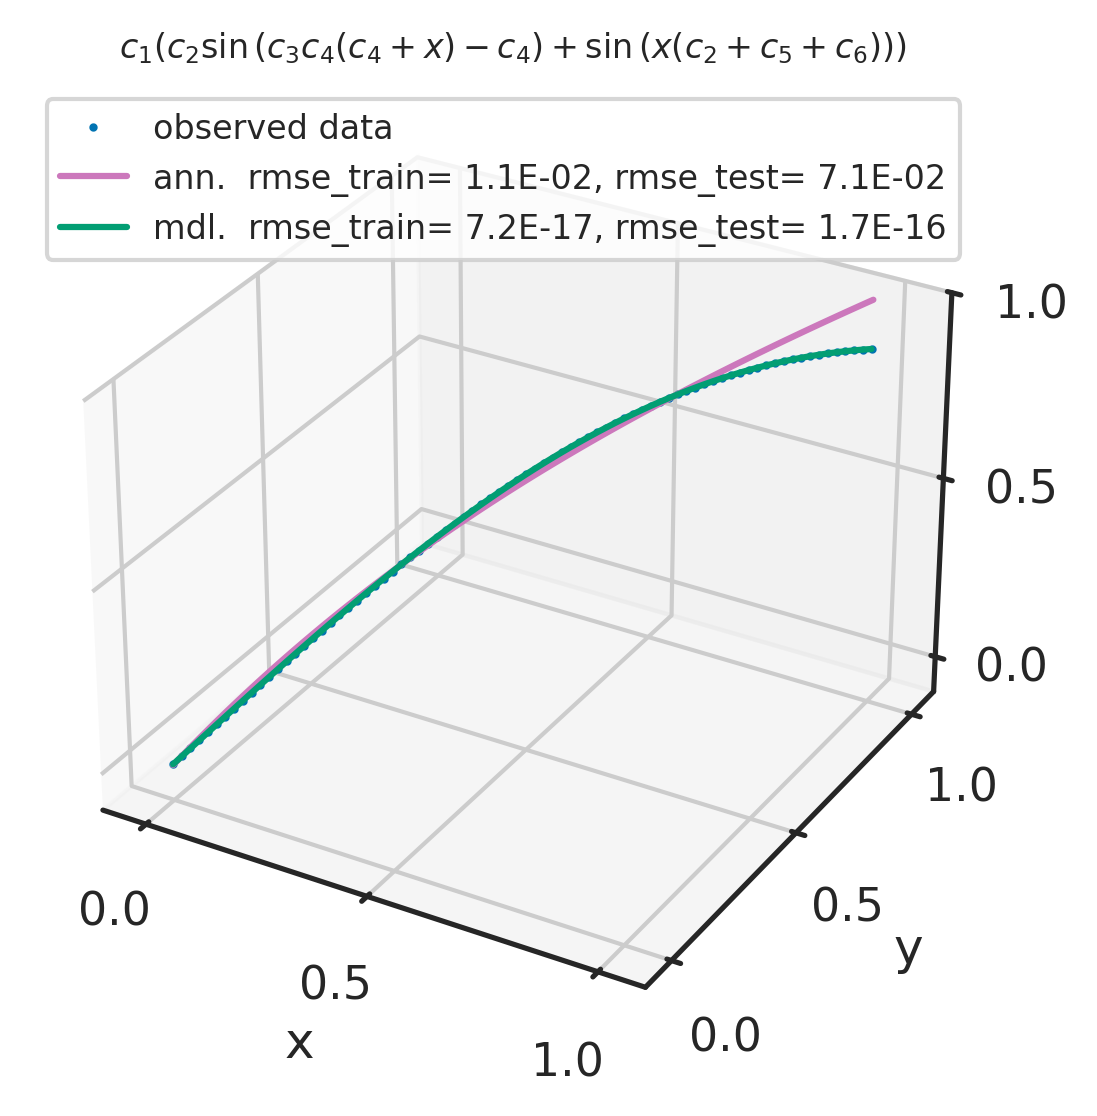

(((sin(((((x + _a5_) * _a0_) * _a5_) + -(_a5_))) * _a1_) + sin((x * ((_a4_ + _a1_) + _a6_)))) * _a7_) {'d0': {'_a0_': 1.0266351791535708, '_a1_': 0.999999999999957, '_a4_': 0.4999890935495308, '_a5_': 0.9740558479833794, '_a6_': 0.5000109064505013, '_a7_': 0.5000000000000089, '_a2_': 1.0, '_a3_': 1.0}}


In [56]:
#Plot 3d nguyen

dplot10 = deepcopy(dng10)

dplot10['ybms'] = t10.predict(x10)

#Errors
rmse_nn_train=root_mean_squared_error(dplot10.loc[:train_size-1]['zmodel'],dplot10.loc[:train_size -1]['z'])
rmse_nn_test=root_mean_squared_error(dplot10.loc[train_size-1:]['zmodel'],dplot10.loc[train_size -1:]['z'])
rmse_mdl_train=root_mean_squared_error(dplot10.loc[:train_size-1]['ybms'],dplot10.loc[:train_size-1]['z'])
rmse_mdl_test =root_mean_squared_error(dplot10.loc[train_size-1:]['ybms'],dplot10.loc[train_size-1:]['z'])

#Plot nguyen function 10
#--------------------------------            
fig=figure(figsize=(width+1,height+1), dpi=300) 
ax=plt.subplot( projection='3d')
#--------------------------------                                                        

plt.plot(dplot10.x, dplot10.y, dplot10.z,'.', markersize=2, color=color_data,label='observed data') 
plt.plot(dplot10.x, dplot10.y, dplot10.zmodel,linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.1E, rmse_test= %.1E' % ( rmse_nn_train, rmse_nn_test)) 
plt.plot(dplot10.x, dplot10.y, dplot10.ybms, color=color_bms,label='mdl.  rmse_train= %.1E, rmse_test= %.1E' % ( rmse_mdl_train, rmse_mdl_test))

plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')


plt.title('$%s$' % t10.latex(),fontsize=size_title)
ax.set_xlabel('x',fontsize=size_ticks);ax.set_ylabel('y',fontsize=size_ticks)
ax.set_xticks(xtick_labels_ng10);ax.set_yticks(ytick_labels_ng10);ax.set_zticks(ztick_labels_ng10)
ax.set_xlim(xmin_ng10,xmax_ng10);ax.set_ylim(ymin_ng10,ymax_ng10);ax.set_zlim(zmin_ng10,zmax_ng10)

ax.legend(loc='upper left', fontsize=size_title)
fig.tight_layout()


Name_figure='Prediction_nguyen' + '_n_' + str(n2) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

    
for ext in extensions:
        plt.savefig('../results/' + Name_figure +ext,dpi=300)

plt.show()


print(t10,t10.par_values)

These are fairly good results, but to a certain extent expected: you would expect a good symbolic regression tool such as the Bayesian Machine Scientist to recover the functions that generated the data originally. Now, what happens if we try to approximate a function generated by an Artificial Neural Network?

### Experiment 2 -  Can ANNs and the BMS approximate ANN-generated functions?

We sampled the space of ANN-generated functions and took 20 functions: **10** using **tanh** as an activation function, **10** using the **leaky ReLU**.

We then added Gaussian noise to these functions from $\sigma=0$ to $\sigma=0.2$ in steps of $\Delta \sigma = 0.02$. That gives **11** levels of noise.

Finally, we make **3** realizations of Gaussian noise for each value $\sigma_i$.

That gives **30** simulations of the BMS and ANNs per value of $\sigma_i$

Below, we show the error for each individual simulation in the approximation task.

In [57]:
errors_approximation=pd.read_csv('../data/'+ 'all_errors' + '.csv',index_col=0)

#take only rmse errors
columns=["sigma", "function","rmse_nn_train", "rmse_nn_test", "rmse_mdl_train", "rmse_mdl_test","n", "r"]
errors_approximation=errors_approximation[columns]

#Melt dataframe to plot
#errors_approximation=pd.melt(errors_approximation,id_vars=["sigma","function","rmse_nn_test","rmse_mdl_test"], var_name="error_train",value_name= "value_train")
#errors_approximation=pd.melt(errors_approximation,id_vars=["sigma","function", "error_train", "value_train"], var_name="error_test", value_name= "value_test")

#display(errors_approximation)


#Melt dataframe to plot and separate train/test
errors_approximation_train=errors_approximation[["sigma","function", "rmse_nn_train", "rmse_mdl_train","n", "r"]]
errors_approximation_train=pd.melt(errors_approximation_train,id_vars=["sigma","function", "n", "r"], var_name="error_train",value_name= "value_train")
display(errors_approximation_train)

errors_approximation_test=errors_approximation[["sigma","function", "rmse_nn_test", "rmse_mdl_test","n", "r"]]
errors_approximation_test=pd.melt(errors_approximation_test,id_vars= ["sigma","function", "n", "r"], var_name="error_test", value_name= "value_test")
display(errors_approximation_test)

,sigma,function,n,r,error_train,value_train
0,0.0,leaky_ReLU,0,0,rmse_nn_train,0.019052
1,0.0,leaky_ReLU,1,0,rmse_nn_train,0.043878
2,0.0,leaky_ReLU,2,0,rmse_nn_train,0.009675
3,0.0,leaky_ReLU,3,0,rmse_nn_train,0.047197
4,0.0,leaky_ReLU,4,0,rmse_nn_train,0.014963
...,...,...,...,...,...,...
1315,0.2,tanh,5,2,rmse_mdl_train,0.040428
1316,0.2,tanh,6,2,rmse_mdl_train,0.118438
1317,0.2,tanh,7,2,rmse_mdl_train,0.116271
1318,0.2,tanh,8,2,rmse_mdl_train,0.077461


,sigma,function,n,r,error_test,value_test
0,0.0,leaky_ReLU,0,0,rmse_nn_test,0.056589
1,0.0,leaky_ReLU,1,0,rmse_nn_test,0.270347
2,0.0,leaky_ReLU,2,0,rmse_nn_test,0.183943
3,0.0,leaky_ReLU,3,0,rmse_nn_test,0.320803
4,0.0,leaky_ReLU,4,0,rmse_nn_test,0.067198
...,...,...,...,...,...,...
1315,0.2,tanh,5,2,rmse_mdl_test,0.134413
1316,0.2,tanh,6,2,rmse_mdl_test,0.277328
1317,0.2,tanh,7,2,rmse_mdl_test,0.031750
1318,0.2,tanh,8,2,rmse_mdl_test,0.427289


In [58]:
#Separate tanh and leaky ReLU
errors_tanh_train=errors_approximation_train[errors_approximation_train['function']=='tanh']
errors_tanh_test=errors_approximation_test[errors_approximation_test['function']=='tanh']

errors_leaky_train=errors_approximation_train[errors_approximation_train['function']=='leaky_ReLU']
errors_leaky_test=errors_approximation_test[errors_approximation_test['function']=='leaky_ReLU']

display(errors_tanh_train)
display(errors_leaky_train)

,sigma,function,n,r,error_train,value_train
330,0.0,tanh,0,0,rmse_nn_train,0.048355
331,0.0,tanh,1,0,rmse_nn_train,0.015287
332,0.0,tanh,2,0,rmse_nn_train,0.119820
333,0.0,tanh,3,0,rmse_nn_train,0.043636
334,0.0,tanh,4,0,rmse_nn_train,0.019958
...,...,...,...,...,...,...
1315,0.2,tanh,5,2,rmse_mdl_train,0.040428
1316,0.2,tanh,6,2,rmse_mdl_train,0.118438
1317,0.2,tanh,7,2,rmse_mdl_train,0.116271
1318,0.2,tanh,8,2,rmse_mdl_train,0.077461


,sigma,function,n,r,error_train,value_train
0,0.0,leaky_ReLU,0,0,rmse_nn_train,0.019052
1,0.0,leaky_ReLU,1,0,rmse_nn_train,0.043878
2,0.0,leaky_ReLU,2,0,rmse_nn_train,0.009675
3,0.0,leaky_ReLU,3,0,rmse_nn_train,0.047197
4,0.0,leaky_ReLU,4,0,rmse_nn_train,0.014963
...,...,...,...,...,...,...
985,0.2,leaky_ReLU,5,2,rmse_mdl_train,0.010952
986,0.2,leaky_ReLU,6,2,rmse_mdl_train,0.140739
987,0.2,leaky_ReLU,7,2,rmse_mdl_train,0.041776
988,0.2,leaky_ReLU,8,2,rmse_mdl_train,0.113643


<Figure size 944.882x826.772 with 0 Axes>

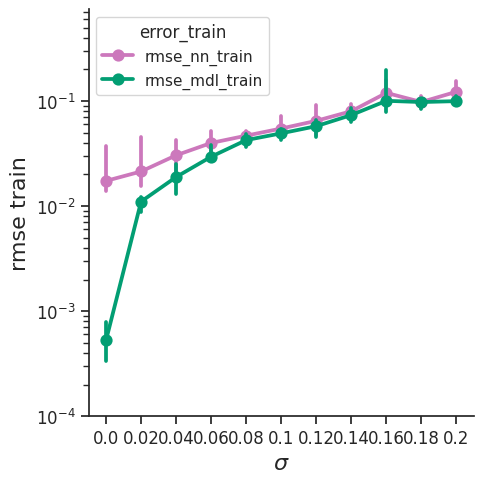

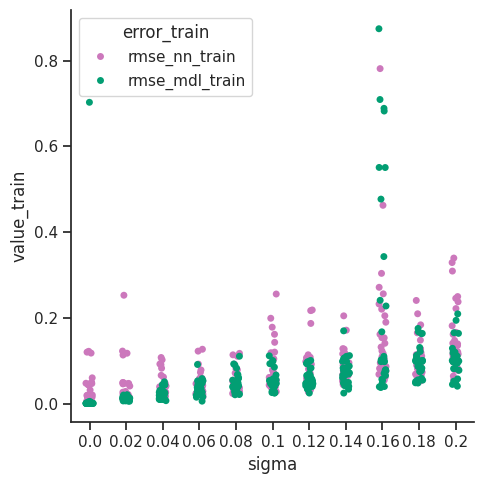

In [59]:
resamples=100000; bs_seed=1111
ymin=1e-4;ymax=0.75

#tanh - rmse approximation
fig=figure(figsize=(width,height), dpi=300)
sns.catplot(data=errors_tanh_train, x='sigma', y='value_train', hue='error_train', kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)


#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse train',fontsize=size_axis)
plt.yscale("log")
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)

plt.ylim(ymin,ymax)

plt.tight_layout()

name_fig='approximation_tanh.png'  
plt.savefig(output_path+name_fig,dpi=300)

#Also plot individual errors of each simulation
sns.catplot(data=errors_tanh_train, x='sigma', y='value_train', hue="error_train",palette=[color_ann, color_bms],legend_out=False)

<Figure size 944.882x826.772 with 0 Axes>

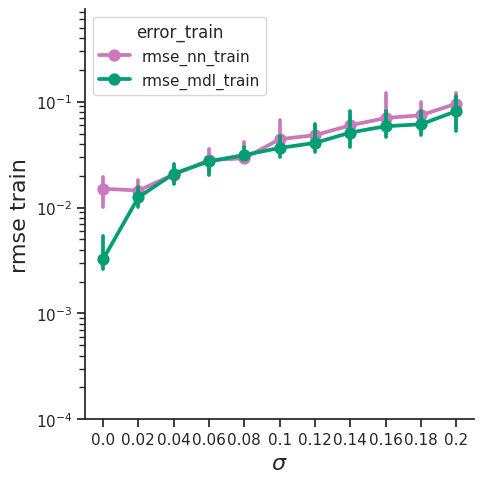

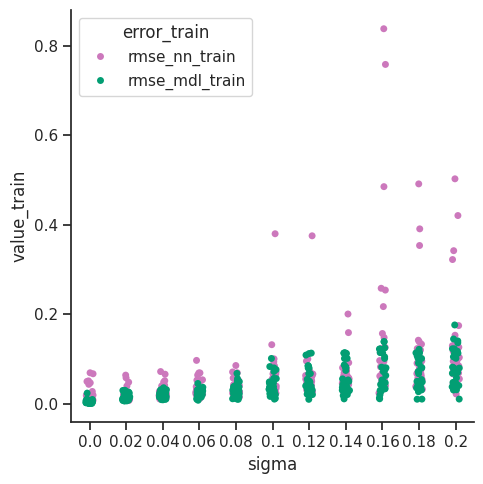

In [60]:
#Approximation: leaky ReLU
fig=figure(figsize=(width,height), dpi=300)

sns.catplot(data=errors_leaky_train, x='sigma', y='value_train', hue="error_train", kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse train',fontsize=size_axis)

plt.ylim(ymin,ymax)

plt.tight_layout()

name_fig='leaky_approximation.png'
plt.savefig(output_path+name_fig,dpi=300)

#Also plot individual errors of each simulation
sns.catplot(data=errors_leaky_train, x='sigma', y='value_train', hue="error_train",palette=[color_ann, color_bms],legend_out=False)

We now look at the errors on the interpolation and extrapolation tasks

In [61]:
#Read errors and take rmse
all_errors_inter_extra=pd.read_csv('../data/'+ 'all_errors_interpolation' + '.csv',index_col=0)
columns=["sigma", "function","rmse_nn_interp.", "rmse_nn_extrap.", "rmse_mdl_interp.", "rmse_mdl_extrap.","r"]
all_errors_inter_extra=all_errors_inter_extra[columns]

#Melt dataframe: make two columns with the type of errors for the train and the values of the errors
errors_inter=all_errors_inter_extra[["sigma", "function","rmse_nn_interp.", "rmse_mdl_interp.","r"]]
errors_inter=pd.melt(errors_inter,id_vars=["sigma","function","r"], var_name="error_interp.",value_name= "value_interp.")

errors_extra=all_errors_inter_extra[["sigma", "function","rmse_nn_extrap.", "rmse_mdl_extrap.","r"]]
errors_extra=pd.melt(errors_extra,id_vars=["sigma","function", "r"], var_name="error_extrap.", value_name= "value_extrap.")

display(errors_inter)

display(errors_extra)

#Separate tanh and leaky ReLU
errors_tanh_inter=errors_inter[errors_inter['function']=='tanh']
errors_tanh_extra=errors_extra[errors_extra['function']=='tanh']

errors_leaky_inter=errors_inter[errors_inter['function']=='leaky_ReLU']
errors_leaky_extra=errors_extra[errors_extra['function']=='leaky_ReLU']

display(errors_tanh_inter)
display(errors_leaky_inter)



#Melt dataframe: make two columns with the type of errors for the train and the values of the errors
#all_errors_inter_extra=pd.melt(all_errors_inter_extra,id_vars=["sigma","function","rmse_nn_extrap.","rmse_mdl_extrap."], var_name="error_interp.",value_name= "value_interp.")

#Melt dataframe: make two columns with the type of errors for the test and the values of the errors
#all_errors_inter_extra=pd.melt(all_errors_inter_extra,id_vars=["sigma","function", "error_interp.", "value_interp."], var_name="error_extrap.", value_name= "value_extrap.")

#split in tanh and leaky
#errors_tanh=all_errors_inter_extra[all_errors_inter_extra['function']=='tanh']
#errors_leaky=all_errors_inter_extra[all_errors_inter_extra['function']=='leaky_ReLU']

#display(errors_tanh)
#display(errors_leaky)

,sigma,function,r,error_interp.,value_interp.
0,0.0,tanh,0,rmse_nn_interp.,0.047852
1,0.0,tanh,0,rmse_nn_interp.,0.015463
2,0.0,tanh,0,rmse_nn_interp.,0.111692
3,0.0,tanh,0,rmse_nn_interp.,0.033141
4,0.0,tanh,0,rmse_nn_interp.,0.010469
...,...,...,...,...,...
1315,0.2,leaky_ReLU,2,rmse_mdl_interp.,0.010784
1316,0.2,leaky_ReLU,2,rmse_mdl_interp.,0.142086
1317,0.2,leaky_ReLU,2,rmse_mdl_interp.,0.041496
1318,0.2,leaky_ReLU,2,rmse_mdl_interp.,0.114628


,sigma,function,r,error_extrap.,value_extrap.
0,0.0,tanh,0,rmse_nn_extrap.,0.052995
1,0.0,tanh,0,rmse_nn_extrap.,0.127937
2,0.0,tanh,0,rmse_nn_extrap.,0.560637
3,0.0,tanh,0,rmse_nn_extrap.,0.101108
4,0.0,tanh,0,rmse_nn_extrap.,0.049501
...,...,...,...,...,...
1315,0.2,leaky_ReLU,2,rmse_mdl_extrap.,0.164822
1316,0.2,leaky_ReLU,2,rmse_mdl_extrap.,0.234066
1317,0.2,leaky_ReLU,2,rmse_mdl_extrap.,0.046699
1318,0.2,leaky_ReLU,2,rmse_mdl_extrap.,0.176435


,sigma,function,r,error_interp.,value_interp.
0,0.0,tanh,0,rmse_nn_interp.,0.047852
1,0.0,tanh,0,rmse_nn_interp.,0.015463
2,0.0,tanh,0,rmse_nn_interp.,0.111692
3,0.0,tanh,0,rmse_nn_interp.,0.033141
4,0.0,tanh,0,rmse_nn_interp.,0.010469
...,...,...,...,...,...
985,0.2,tanh,2,rmse_mdl_interp.,0.038005
986,0.2,tanh,2,rmse_mdl_interp.,0.116825
987,0.2,tanh,2,rmse_mdl_interp.,0.116529
988,0.2,tanh,2,rmse_mdl_interp.,0.076724


,sigma,function,r,error_interp.,value_interp.
330,0.0,leaky_ReLU,0,rmse_nn_interp.,0.019390
331,0.0,leaky_ReLU,0,rmse_nn_interp.,0.044218
332,0.0,leaky_ReLU,0,rmse_nn_interp.,0.009902
333,0.0,leaky_ReLU,0,rmse_nn_interp.,0.044113
334,0.0,leaky_ReLU,0,rmse_nn_interp.,0.013290
...,...,...,...,...,...
1315,0.2,leaky_ReLU,2,rmse_mdl_interp.,0.010784
1316,0.2,leaky_ReLU,2,rmse_mdl_interp.,0.142086
1317,0.2,leaky_ReLU,2,rmse_mdl_interp.,0.041496
1318,0.2,leaky_ReLU,2,rmse_mdl_interp.,0.114628


<Figure size 944.882x826.772 with 0 Axes>

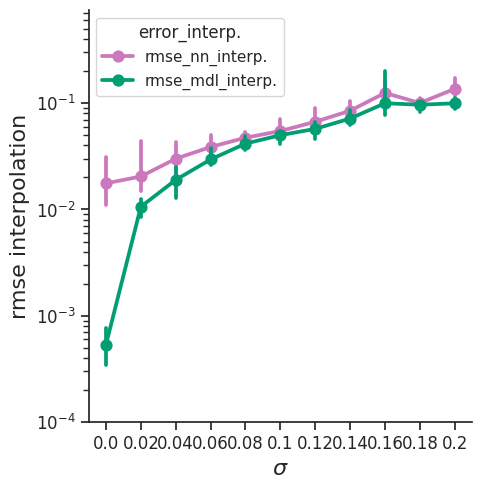

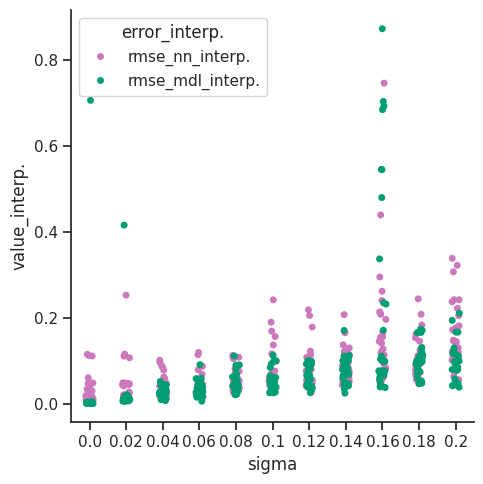

In [62]:
#Interpolation - tanh
fig=figure(figsize=(width,height), dpi=300)
sns.catplot(data=errors_tanh_inter, x='sigma', y='value_interp.', hue="error_interp.", kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)

plt.ylim(ymin,ymax)

#Also plot individual errors of each simulation
sns.catplot(data=errors_tanh_inter, x='sigma', y='value_interp.', hue="error_interp.",palette=[color_ann, color_bms],legend_out=False)

<Figure size 944.882x826.772 with 0 Axes>

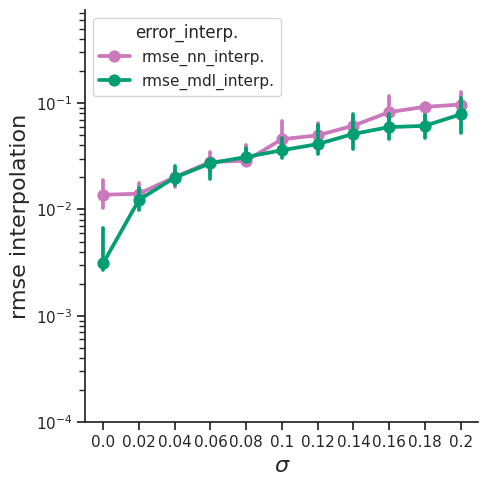

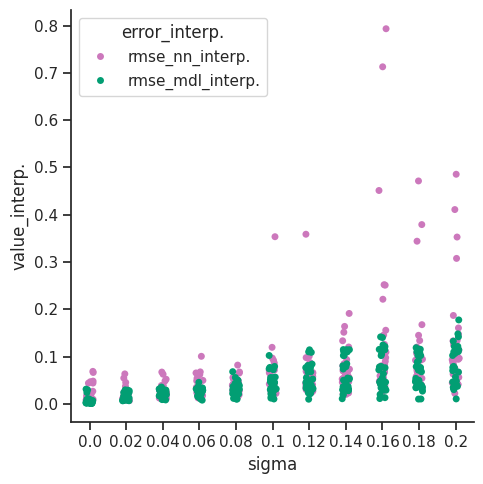

In [63]:
#Interpolation - leaky
fig=figure(figsize=(width,height), dpi=300)

sns.catplot(data=errors_leaky_inter, x='sigma', y='value_interp.', hue='error_interp.', kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.ylim(ymin,ymax)

#Also plot individual errors of each simulation
sns.catplot(data=errors_leaky_inter, x='sigma', y='value_interp.', hue='error_interp.',palette=[color_ann, color_bms],legend_out=False)

<Figure size 944.882x826.772 with 0 Axes>

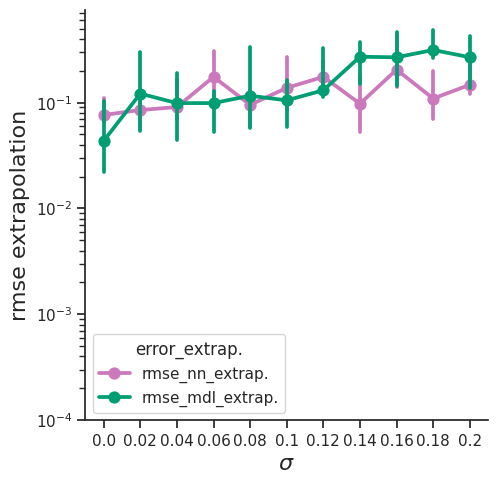

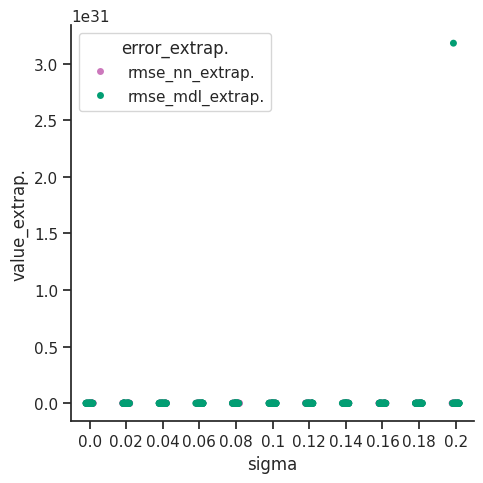

In [64]:
#Extrapolation - tanh
fig=figure(figsize=(width,height), dpi=300)

sns.catplot(data=errors_tanh_extra, x='sigma', y='value_extrap.', hue="error_extrap.", kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.ylim(ymin,ymax)

#Also plot individual errors of each simulation
sns.catplot(data=errors_tanh_extra, x='sigma', y='value_extrap.', hue="error_extrap.",palette=[color_ann, color_bms],legend_out=False)

<Figure size 944.882x826.772 with 0 Axes>

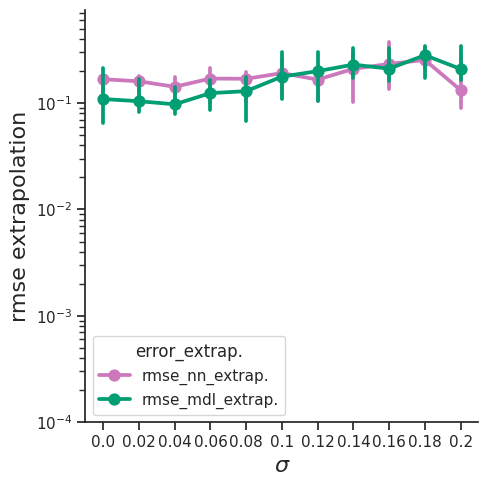

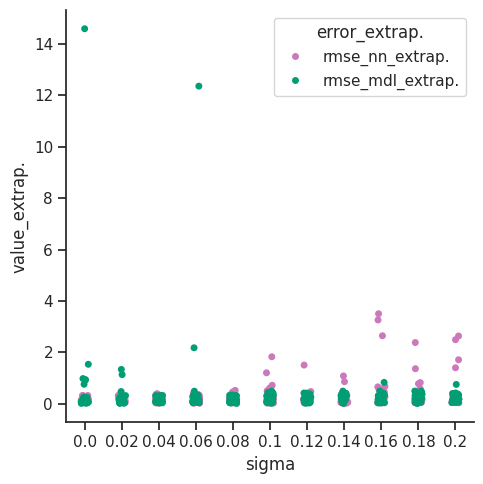

In [65]:
#Extrapolation - leaky
fig=figure(figsize=(width,height), dpi=300)

sns.catplot(data=errors_leaky_extra, x='sigma', y='value_extrap.', hue='error_extrap.', kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.ylim(ymin,ymax)

#Also plot individual errors of each simulation
sns.catplot(data=errors_leaky_extra, x='sigma', y='value_extrap.', hue='error_extrap.',palette=[color_ann, color_bms],legend_out=False)